# Gate corto con train y validation separados

Este notebook prueba si el objetivo predictivo mejora sobre **secuencias no vistas durante la optimización** sin colapso completo de la representación. Ejecuta exactamente `configs/paper_train_validation_smoke.yaml`, cuyos hiperparámetros y umbrales fueron congelados antes de observar los resultados.

Sigue siendo una condición local de desarrollo: no reproduce todavía el entrenamiento completo ni los resultados de clustering u operador del paper.

## Protocolo y gates previos

Train contiene 32 secuencias por régimen y validation 8, con splits deterministas y disjuntos. El test queda reservado. Evaluamos el modelo sin entrenar en la época 0 y luego recorremos train y validation completos después de cada una de las diez épocas.

El gate exige valores finitos, validation loss final no mayor al 50% de la baseline, ratio validation/train no mayor a 4, al menos 10% de la dispersión inicial de validation y rango efectivo de validation de al menos 4. El resultado final promedia las últimas dos épocas.

In [1]:
# ruff: noqa: E402, E501
import json
import platform
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "No se encontró la raíz del repositorio."
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import load_paper_train_validation_config
from koopman_jepa.paper_data import (
    PAPER_REGIME_NAMES,
    PaperRegimeDataset,
    generate_paper_master,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_validation_gate,
    run_paper_train_validation,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

Python: 3.13.12
NumPy: 2.5.3
PyTorch: 2.14.0


In [2]:
config_path = ROOT / "configs" / "paper_train_validation_smoke.yaml"
config = load_paper_train_validation_config(config_path)

random.seed(config.train.seed)
np.random.seed(config.train.seed)
torch.manual_seed(config.train.seed)
torch.use_deterministic_algorithms(True)

print(config_path.relative_to(ROOT))
print(json.dumps(asdict(config), indent=2))

configs/paper_train_validation_smoke.yaml
{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 32,
    "val_per_regime": 8,
    "test_per_regime": 8,
    "base_seed": 0,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "linear",
    "linear_initialization": "identity",
    "mlp_depth": "two_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 10,
    "seed": 0,
    "device": "cpu",
    "num_workers": 0
  },
  "gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  }
}


## Splits

La separación ocurre por ID de master dentro de cada régimen. Por ejemplo, para el régimen 0 train utiliza IDs 0–31, validation 32–39 y test quedaría en 40–47. No se ajustan hiperparámetros ni estadísticas con test.

In [3]:
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)

train_keys = {train_dataset.sample_key(index) for index in range(len(train_dataset))}
validation_keys = {
    validation_dataset.sample_key(index) for index in range(len(validation_dataset))
}
assert train_keys.isdisjoint(validation_keys)
assert len(train_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert len(validation_dataset) == 8 * len(PAPER_REGIME_NAMES) == 144

print(f"Train: {len(train_dataset)} secuencias ({config.data.train_per_regime} por régimen)")
print(f"Validation: {len(validation_dataset)} secuencias ({config.data.val_per_regime} por régimen)")
print(f"Test reservado: {config.data.test_per_regime * len(PAPER_REGIME_NAMES)} secuencias")
print("Intersección train/validation: 0 — PASS")

Train: 576 secuencias (32 por régimen)
Validation: 144 secuencias (8 por régimen)
Test reservado: 144 secuencias
Intersección train/validation: 0 — PASS


## Entrenamiento y evaluación

La época 0 es la baseline del modelo recién inicializado. Cada época posterior usa minibatches de train barajados reproduciblemente; validation nunca actualiza parámetros ni EMA. Las loss mostradas se recalculan recorriendo cada split completo después de la época.

In [4]:
model = PaperTemporalJEPA(config.model)
started = time.perf_counter()
history = run_paper_train_validation(
    model,
    train_dataset,
    validation_dataset,
    config.train,
)
elapsed = time.perf_counter() - started
gate = evaluate_validation_gate(history, config.gate)

assert [row.epoch for row in history] == list(range(config.train.epochs + 1))
print(f"Tiempo total: {elapsed:.2f} s")
print(json.dumps(asdict(gate), indent=2))

Tiempo total: 9.57 s
{
  "all_finite": true,
  "initial_validation_loss": 0.006769400296939744,
  "final_train_loss": 0.00043124725986369106,
  "final_validation_loss": 0.0016663539378593364,
  "validation_loss_ratio": 0.2461597578462967,
  "validation_train_loss_ratio": 3.864033683103375,
  "initial_validation_embedding_std": 0.009328348562121391,
  "final_validation_embedding_std": 0.006245538825169206,
  "validation_embedding_std_ratio": 0.6695224544384828,
  "final_validation_effective_rank": 20.93353271484375,
  "loss_passed": true,
  "generalization_gap_passed": true,
  "spread_passed": true,
  "rank_passed": true,
  "passed": true
}


In [5]:
print("epoch  train_loss    val_loss      val/train   val_std      val_rank")
for row in history:
    gap = row.validation_loss / max(row.train_loss, 1e-12)
    print(
        f"{row.epoch:>5d}  {row.train_loss:>11.6g}  {row.validation_loss:>11.6g}  "
        f"{gap:>9.3f}   {row.validation_embedding_std:>9.6f}  "
        f"{row.validation_effective_rank:>8.3f}"
    )

epoch  train_loss    val_loss      val/train   val_std      val_rank
    0   0.00670722    0.0067694      1.009    0.009328    21.615
    1    0.0080931   0.00876681      1.083    0.006189    24.599
    2   0.00413692   0.00435913      1.054    0.005498    23.837
    3   0.00260444   0.00305405      1.173    0.005539    21.411
    4   0.00187032   0.00234064      1.251    0.005956    18.298
    5    0.0014771   0.00208962      1.415    0.006010    17.814
    6   0.00118341   0.00190829      1.613    0.006123    17.656
    7  0.000917802   0.00181154      1.974    0.006159    18.498
    8  0.000697968   0.00172428      2.470    0.006207    19.633
    9  0.000492527   0.00167994      3.411    0.006225    20.666
   10  0.000369968   0.00165277      4.467    0.006266    21.201


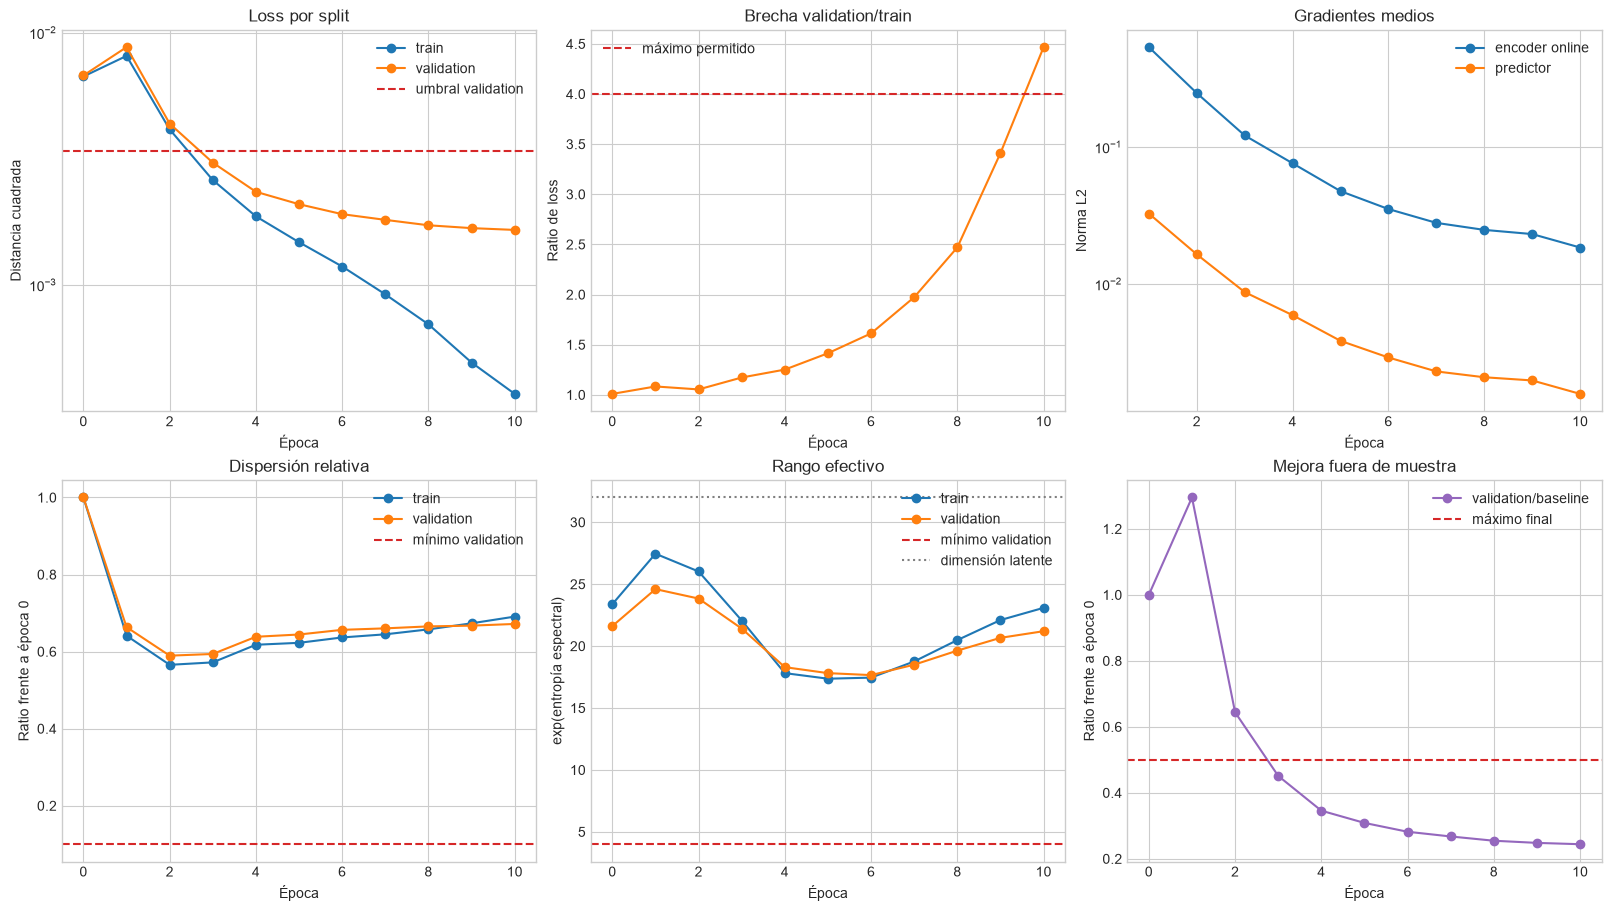

In [6]:
epochs = np.array([row.epoch for row in history])
train_loss = np.array([row.train_loss for row in history])
validation_loss = np.array([row.validation_loss for row in history])
loss_gap = validation_loss / np.maximum(train_loss, 1e-12)
train_std = np.array([row.train_embedding_std for row in history])
validation_std = np.array([row.validation_embedding_std for row in history])
train_rank = np.array([row.train_effective_rank for row in history])
validation_rank = np.array([row.validation_effective_rank for row in history])
online_gradient = np.array([row.online_gradient_norm for row in history])
predictor_gradient = np.array([row.predictor_gradient_norm for row in history])

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

axes[0, 0].semilogy(epochs, np.maximum(train_loss, 1e-12), marker="o", label="train")
axes[0, 0].semilogy(epochs, np.maximum(validation_loss, 1e-12), marker="o", label="validation")
axes[0, 0].axhline(history[0].validation_loss * config.gate.max_validation_loss_ratio, color="tab:red", linestyle="--", label="umbral validation")
axes[0, 0].set(title="Loss por split", xlabel="Época", ylabel="Distancia cuadrada")
axes[0, 0].legend()

axes[0, 1].plot(epochs, loss_gap, marker="o", color="tab:orange")
axes[0, 1].axhline(config.gate.max_validation_train_loss_ratio, color="tab:red", linestyle="--", label="máximo permitido")
axes[0, 1].set(title="Brecha validation/train", xlabel="Época", ylabel="Ratio de loss")
axes[0, 1].legend()

axes[0, 2].semilogy(epochs[1:], np.maximum(online_gradient[1:], 1e-12), marker="o", label="encoder online")
axes[0, 2].semilogy(epochs[1:], np.maximum(predictor_gradient[1:], 1e-12), marker="o", label="predictor")
axes[0, 2].set(title="Gradientes medios", xlabel="Época", ylabel="Norma L2")
axes[0, 2].legend()

axes[1, 0].plot(epochs, train_std / train_std[0], marker="o", label="train")
axes[1, 0].plot(epochs, validation_std / validation_std[0], marker="o", label="validation")
axes[1, 0].axhline(config.gate.min_validation_embedding_std_ratio, color="tab:red", linestyle="--", label="mínimo validation")
axes[1, 0].set(title="Dispersión relativa", xlabel="Época", ylabel="Ratio frente a época 0")
axes[1, 0].legend()

axes[1, 1].plot(epochs, train_rank, marker="o", label="train")
axes[1, 1].plot(epochs, validation_rank, marker="o", label="validation")
axes[1, 1].axhline(config.gate.min_validation_effective_rank, color="tab:red", linestyle="--", label="mínimo validation")
axes[1, 1].axhline(config.model.latent_dim, color="0.5", linestyle=":", label="dimensión latente")
axes[1, 1].set(title="Rango efectivo", xlabel="Época", ylabel="exp(entropía espectral)")
axes[1, 1].legend()

axes[1, 2].plot(epochs, validation_loss / validation_loss[0], marker="o", color="tab:purple", label="validation/baseline")
axes[1, 2].axhline(config.gate.max_validation_loss_ratio, color="tab:red", linestyle="--", label="máximo final")
axes[1, 2].set(title="Mejora fuera de muestra", xlabel="Época", ylabel="Ratio frente a época 0")
axes[1, 2].legend()

plt.show()

In [7]:
status = "PASS" if gate.passed else "FAIL"
best_validation_epoch = int(validation_loss.argmin())
best_validation_loss = float(validation_loss.min())
minimum_validation_std_epoch = int(validation_std.argmin())
minimum_validation_rank_epoch = int(validation_rank.argmin())
passing_validation_epochs = epochs[
    validation_loss / validation_loss[0] <= config.gate.max_validation_loss_ratio
]
first_passing_validation_epoch = (
    int(passing_validation_epochs[0]) if passing_validation_epochs.size else None
)
final_epoch_gap = float(loss_gap[-1])
last_epoch_validation_improvement = 1.0 - validation_loss[-1] / validation_loss[-2]
last_epoch_train_improvement = 1.0 - train_loss[-1] / train_loss[-2]
decision = (
    "El gate agregado pasa, pero no abrimos test todavía: primero debemos fijar una política de checkpoint y comprobar estabilidad entre seeds debido a la brecha creciente."
    if gate.passed
    else "El gate no habilita evaluación en test; primero hay que explicar qué criterio falló."
)

display(Markdown(f"""## Resultado e interpretación

- **Gate global: {status}.**
- **Mejora de validation:** la loss pasó de `{gate.initial_validation_loss:.6g}` a una media final de `{gate.final_validation_loss:.6g}`; ratio `{gate.validation_loss_ratio:.4f}` frente al máximo `{config.gate.max_validation_loss_ratio:.2f}`.
- **Brecha final:** validation/train = `{gate.validation_train_loss_ratio:.3f}` frente al máximo `{config.gate.max_validation_train_loss_ratio:.1f}`.
- **Dispersión de validation:** retuvo `{gate.validation_embedding_std_ratio:.1%}` de la baseline frente al mínimo `{config.gate.min_validation_embedding_std_ratio:.1%}`.
- **Rango efectivo de validation:** `{gate.final_validation_effective_rank:.3f}` frente al mínimo `{config.gate.min_validation_effective_rank:.1f}`.
- **Estabilidad numérica:** {'PASS' if gate.all_finite else 'FAIL'}.

### Lectura de las curvas

Validation empeora inicialmente y recién cruza el umbral de 50% en la época `{first_passing_validation_epoch}`. Su mejor valor individual es `{best_validation_loss:.6g}` en la época `{best_validation_epoch}`. En la última época mejora sólo `{last_epoch_validation_improvement:.1%}`, mientras train mejora `{last_epoch_train_improvement:.1%}`: la separación de velocidades revela sobreajuste creciente aunque validation todavía no haya empeorado.

La brecha individual de la época final es `{final_epoch_gap:.3f}` y supera el límite 4.0. El gate predefinido sigue siendo PASS porque calcula el cociente entre las loss medias de las épocas 9–10 (`{gate.validation_train_loss_ratio:.3f}`); no cambiamos esa regla después de ver el resultado, pero registramos la señal.

La menor dispersión de validation ocurrió en la época `{minimum_validation_std_epoch}` (`{validation_std.min():.6g}`) y el menor rango efectivo en la época `{minimum_validation_rank_epoch}` (`{validation_rank.min():.3f}`). Ambos se recuperan, de modo que el plateau de validation no se explica por colapso completo del latente.

### Decisión

{decision} Incluso con PASS, este smoke test **no reproduce** la pureza de clustering ni los diagnósticos del operador lineal del paper; sólo establece mejora predictiva fuera de train bajo una condición local pequeña.
"""))

## Resultado e interpretación

- **Gate global: PASS.**
- **Mejora de validation:** la loss pasó de `0.0067694` a una media final de `0.00166635`; ratio `0.2462` frente al máximo `0.50`.
- **Brecha final:** validation/train = `3.864` frente al máximo `4.0`.
- **Dispersión de validation:** retuvo `67.0%` de la baseline frente al mínimo `10.0%`.
- **Rango efectivo de validation:** `20.934` frente al mínimo `4.0`.
- **Estabilidad numérica:** PASS.

### Lectura de las curvas

Validation empeora inicialmente y recién cruza el umbral de 50% en la época `3`. Su mejor valor individual es `0.00165277` en la época `10`. En la última época mejora sólo `1.6%`, mientras train mejora `24.9%`: la separación de velocidades revela sobreajuste creciente aunque validation todavía no haya empeorado.

La brecha individual de la época final es `4.467` y supera el límite 4.0. El gate predefinido sigue siendo PASS porque calcula el cociente entre las loss medias de las épocas 9–10 (`3.864`); no cambiamos esa regla después de ver el resultado, pero registramos la señal.

La menor dispersión de validation ocurrió en la época `2` (`0.00549809`) y el menor rango efectivo en la época `6` (`17.656`). Ambos se recuperan, de modo que el plateau de validation no se explica por colapso completo del latente.

### Decisión

El gate agregado pasa, pero no abrimos test todavía: primero debemos fijar una política de checkpoint y comprobar estabilidad entre seeds debido a la brecha creciente. Incluso con PASS, este smoke test **no reproduce** la pureza de clustering ni los diagnósticos del operador lineal del paper; sólo establece mejora predictiva fuera de train bajo una condición local pequeña.
